# Figure 4: Distinct Excitation/Inhibition Balance Effects of Perisomatic and Distal Dendritic Inhibition

This notebook analyzes simulations from [Headley et al. (eLife, 2026): "Spatially targeted inhibitory rhythms differentially affect neuronal integration"](https://doi.org/10.7554/eLife.95562).

## Background
In vivo, inhibition is dynamic and time-varying. PV and SOM interneurons form dense interconnections with local pyramidal neurons, supplying time-lagged feedback inhibition. This helps maintain the balance of excitation and inhibition (E/I) in the network by ensuring that an overall increase in excitatory activity is rapidly counterbalanced by proportionate inhibition.

## Simulation Design
To emulate situations where E/I balance is important, excitatory drive had increased dynamic variation. The rate of inhibitory synaptic drive was a lagged and rescaled version of the overall excitation rate. Normally that lag is 4 ms, in line with experimental estimates. To probe whether perisomatic or distal dendritic inhibition have distinct effects on E/I balance, we independently varied their lags. One was kept at the nominal 4 ms lag, while the other was extended to 10, 50, 125, 250, or 500 ms.

## Key Findings
- Increasing the lag of perisomatic inhibition lowered action potential firing
- Distal dendritic inhibition lag decreased the firing rate out to 125 ms, then returned to normal at 500 ms
- Distal and perisomatic inhibition modulate the coupling between synaptic drive and spiking through distinct processes
- The normal 4 ms E/I lag produced maximal conversion of dendritic spiking events into action potentials

In [1]:
import os
import sys
sys.path.append('..') # have to do this for relative imports in jupyter
import re
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from src.load_v_h5 import load_v_h5
from src.sta_files import sta_files
from src.load_caspks_csv import load_caspks_csv
from src.load_spike_h5 import load_spike_h5
from src.cc_serser import cc_serser
from src.count_dendevt_files import count_dendevt_files

# 1.0 Analysis Parameters

Parameters for computing spike-triggered averages (STAs) between dendritic spikes and action potentials. The STA measures the percent change in dendritic spike incidence relative to the mean rate across the entire simulation, providing insight into the temporal relationship between dendritic events and somatic spiking.

In [2]:
samps_per_ms = 10 
sim_win = [0, 1500000] # beginning and start points of simulation in samples
sta_win = [-300, 300] # multiply by step to get window in milliseconds
sta_step = 1 # binning step for each point in the STA
step = 2 * samps_per_ms # number of simulation steps for creating the dendritic 
                        # event occurrence series

## 1.1 Simulation Files

Simulations with varying excitation-inhibition (E/I) lags on perisomatic and distal dendrite compartments. Each simulation varied the lag of inhibition relative to excitation:
- **Perisomatic lags (prox)**: 4, 10, 50, 125, 250, 500 ms (with distal fixed at 4 ms)
- **Distal dendritic lags (dist)**: 4, 10, 50, 125, 250, 500 ms (with perisomatic fixed at 4 ms)
- **Negative lags**: Conditions where inhibition precedes excitation (e.g., proxn50, proxn500)

The 4 ms lag represents the nominal feedforward inhibition delay based on experimental estimates (Wehr & Zador, 2003).

In [3]:
# locate simulation files
root_dir = 'D:\\DendCompOscPublic\\Fig4\\'
sim_dict = [{'SimName': 'prox500_dist_4',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_500_dist_4',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'prox250_dist_4',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_250_dist_4',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'prox125_dist_4',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_125_dist_4',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'prox50_dist_4',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_50_dist_4',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'prox10_dist_4',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_10_dist_4',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'prox4_dist_4',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_4_dist_4',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'prox4_dist_500',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_4_dist_500',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'prox4_dist_250',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_4_dist_250',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'prox4_dist_125',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_4_dist_125',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'prox4_dist_50',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_4_dist_50',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'prox4_dist_10',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_4_dist_10',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'proxn50_dist_4',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_n50_dist_4',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'proxn10_dist_4',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_n10_dist_4',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'proxn500_dist_4',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_n500_dist_4',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'prox4_dist_n500',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_4_dist_n500',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'prox4_dist_n50',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_4_dist_n50',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'},
            {'SimName': 'prox4_dist_n10',
            'RootDir': root_dir,
            'SimDir': 'output_EI_prox_4_dist_n10',
            'CaFileSuffix': '_ca.csv',
            'NaFileSuffix': '_na.csv',
            'NMDAFileSuffix': '_nmda.csv',
            'APFile': 'spikes.h5'}]

sim_df = pd.DataFrame(sim_dict)
sim_df.set_index('SimName', inplace=True)
sim_df



,RootDir,SimDir,CaFileSuffix,NaFileSuffix,NMDAFileSuffix,APFile
SimName,,,,,,
prox500_dist_4,D:\DendCompOscPublic\Fig4\,output_EI_prox_500_dist_4,_ca.csv,_na.csv,_nmda.csv,spikes.h5
prox250_dist_4,D:\DendCompOscPublic\Fig4\,output_EI_prox_250_dist_4,_ca.csv,_na.csv,_nmda.csv,spikes.h5
prox125_dist_4,D:\DendCompOscPublic\Fig4\,output_EI_prox_125_dist_4,_ca.csv,_na.csv,_nmda.csv,spikes.h5
prox50_dist_4,D:\DendCompOscPublic\Fig4\,output_EI_prox_50_dist_4,_ca.csv,_na.csv,_nmda.csv,spikes.h5
prox10_dist_4,D:\DendCompOscPublic\Fig4\,output_EI_prox_10_dist_4,_ca.csv,_na.csv,_nmda.csv,spikes.h5
prox4_dist_4,D:\DendCompOscPublic\Fig4\,output_EI_prox_4_dist_4,_ca.csv,_na.csv,_nmda.csv,spikes.h5
prox4_dist_500,D:\DendCompOscPublic\Fig4\,output_EI_prox_4_dist_500,_ca.csv,_na.csv,_nmda.csv,spikes.h5
prox4_dist_250,D:\DendCompOscPublic\Fig4\,output_EI_prox_4_dist_250,_ca.csv,_na.csv,_nmda.csv,spikes.h5
prox4_dist_125,D:\DendCompOscPublic\Fig4\,output_EI_prox_4_dist_125,_ca.csv,_na.csv,_nmda.csv,spikes.h5


# 2.0 Spike-Triggered Averages for Dendritic Spikes

Compute STAs between somatic action potentials and dendritic spikes (Ca²⁺, Na⁺, and NMDA). The STAs are grouped by:
- **Electrotonic distance**: Dendritic compartments binned into deciles by their electrotonic distance from the soma
- **Dendritic type**: Apical vs. basal dendrites
- **Spike type**: Ca²⁺, NMDA, and Na⁺ dendritic spikes

This analysis reveals how the timing of dendritic spikes relates to somatic action potentials, and how different E/I lags affect this coupling.

In [4]:
# process the simulations
lag_sta = []

for sim_name, sim_dict in sim_df.iterrows():
    print(sim_name)
    sim_dir = os.path.join(sim_dict['RootDir'], sim_dict['SimDir'])
    ca_path = os.path.join(sim_dir, sim_dict['SimDir'] + sim_dict['CaFileSuffix'])
    na_path = os.path.join(sim_dir, sim_dict['SimDir'] + sim_dict['NaFileSuffix'])
    nmda_path = os.path.join(sim_dir, sim_dict['SimDir'] + sim_dict['NMDAFileSuffix'])
    ap_path = os.path.join(sim_dir, sim_dict['APFile'])
    proc_temp = {'sim_name': sim_name}
    proc_temp['ca_sta'] = sta_files(ca_path, ap_path, step, sim_win,
                                    sta_step,sta_win, agg_colname='Elec_distanceQ')
    proc_temp['nmda_sta'] = sta_files(nmda_path, ap_path, step, sim_win,
                                      sta_step,sta_win, agg_colname='Elec_distanceQ')
    proc_temp['na_sta'] = sta_files(na_path, ap_path, step, sim_win,
                                    sta_step,sta_win, agg_colname='Elec_distanceQ')
    lag_sta.append(proc_temp)



prox500_dist_4


c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\.conda\envs\dend_comp\lib\site-packages\scipy\stats\_axis_nan_policy.py:527: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\.conda\envs\dend_comp\lib\site-packages\scipy\stats\_axis_nan_policy.py:527: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Resul

prox250_dist_4


c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\.conda\envs\dend_comp\lib\site-packages\scipy\stats\_axis_nan_policy.py:527: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\.cond

prox125_dist_4


...

c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\.conda\envs\dend_comp\lib\site-packages\scipy\stats\_axis_nan_policy.py:527: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\.cond

prox4_dist_n50


c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\.conda\envs\dend_comp\lib\site-packages\scipy\stats\_axis_nan_policy.py:527: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\.cond

prox4_dist_n10


c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\.conda\envs\dend_comp\lib\site-packages\scipy\stats\_axis_nan_policy.py:527: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\.cond

# 3.0 STA Visualization

## 3.1 Plotting Functions and Percent Change in Dendritic Event Occurrence

Visualize the spike-triggered averages showing the percent change in dendritic spike incidence centered on action potentials. 

Key observations from the paper:
- **Lagging distal inhibition** clusters dendritic spikes together in time, during which action potentials are emitted
- **Lagging perisomatic inhibition** does not affect dendritic spike spacing, but decreases their coupling with somatic spiking
- **Ca²⁺ spike coordination** with APs decreases as E/I lag increases, with distal inhibition also broadening their temporal relationship
- **NMDA spikes** in apical branches show similar patterns, while basal branches are relatively unaffected

In [5]:
t_list = np.arange(sta_win[0], sta_win[1], sta_step) * (step / samps_per_ms)
eqt_list = np.arange(9,-1,-1)

t_inds = np.where(np.abs(t_list)<=50)[0]
eqt_inds = np.arange(0,10)#np.where(eqt_list>0)[0]

def plot_sta_im(data_arr,ax,**kwargs):

    # Plot the data array as an image
    ax_im = ax.imshow(data_arr[eqt_inds[0]:eqt_inds[-2],t_inds[0]:t_inds[-1]], 
                      extent=[t_list[t_inds[0]], t_list[t_inds[-1]],
                              eqt_list[eqt_inds[0]], eqt_list[eqt_inds[-2]]],
                      interpolation='none',
                      cmap='coolwarm',
                      norm=colors.CenteredNorm(vcenter=0), 
                      **kwargs)
    
    # Plot the color bar
    plt.colorbar(ax_im,ax=ax)
    
    # Plot the vertical axis
    ax.axvline(0,color='white',linestyle=':')
    
    # Set the aspect ratio of the plot
    ax.set_aspect('auto')

def plot_sta_stair(data_arr,ax):
    mean_data = np.mean(data_arr[eqt_inds[0]:eqt_inds[-1],t_inds[0]:t_inds[-1]],0)

    ax_im = ax.stairs(mean_data, np.hstack((t_list[t_inds[:-1]], t_list[t_inds[-1]])),
                     fill=True, baseline=0)
    
    ax.axvline(0,color='black',linestyle=':')
    ax.set_aspect('auto')

In [6]:
def mean_sta(data_arr):
    return np.mean(data_arr[eqt_inds[0]:eqt_inds[-1],t_inds[0]:t_inds[-1]],0)

In [7]:
def plot_sta_means(data, sim_list, sta_type, dend_sec, ax):
    for sim_name in sim_list:
        # find index of data where sim_name field matches sim_name
        sim_ind = [i for i, curr in enumerate(data) if curr['sim_name']==sim_name][0]
        mean_data = mean_sta(data[sim_ind][sta_type].loc[dend_sec].sta)

        # extract largest number from string sim_name
        max_num = max(map(int, re.findall(r'\d+', sim_name)))
        ax.plot(t_list[t_inds[:-1]], mean_data, label=max_num)
    ax.axvline(0,color='black',linestyle=':')
    ax.legend()
    ax.set_aspect('auto')

def plot_sta_means_rel(data, sim_list, sta_type, dend_sec, ax):
    for sim_name in sim_list:
        # find index of data where sim_name field matches sim_name
        sim_ind = [i for i, curr in enumerate(data) if curr['sim_name']==sim_name][0]
        mean_data = mean_sta(data[sim_ind][sta_type].loc[dend_sec].sta)
        mean_data = mean_data / np.max(np.abs(mean_data))
        # extract largest number from string sim_name
        max_num = max(map(int, re.findall(r'\d+', sim_name)))
        ax.plot(t_list[t_inds[:-1]], mean_data, label=max_num)
    ax.axvline(0,color='black',linestyle=':')
    ax.legend()
    ax.set_aspect('auto')

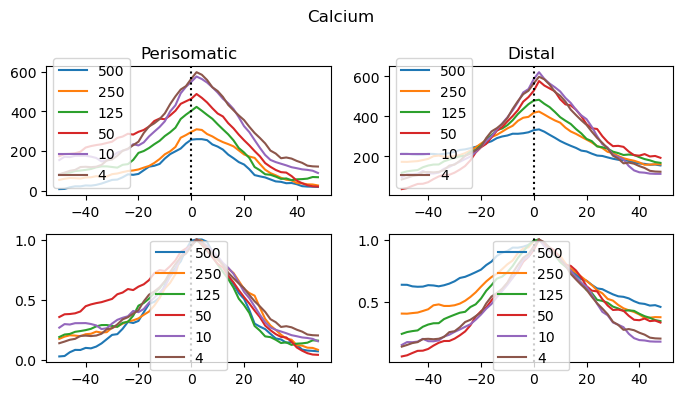

In [8]:

fig, ax = plt.subplots(2,2,figsize=(7,4))
plot_sta_means(lag_sta, ['prox500_dist_4','prox250_dist_4','prox125_dist_4','prox50_dist_4','prox10_dist_4', 'prox4_dist_4'],
               'ca_sta', 'apic', ax[0,0])
ax[0,0].set_title('Perisomatic')
plot_sta_means(lag_sta, ['prox4_dist_500','prox4_dist_250','prox4_dist_125','prox4_dist_50','prox4_dist_10', 'prox4_dist_4'],
               'ca_sta', 'apic', ax[0,1])
ax[0,1].set_title('Distal')
plot_sta_means_rel(lag_sta, ['prox500_dist_4','prox250_dist_4','prox125_dist_4','prox50_dist_4','prox10_dist_4', 'prox4_dist_4'],
               'ca_sta', 'apic', ax[1,0])
plot_sta_means_rel(lag_sta, ['prox4_dist_500','prox4_dist_250','prox4_dist_125','prox4_dist_50','prox4_dist_10', 'prox4_dist_4'],
               'ca_sta', 'apic', ax[1,1])
fig.suptitle('Calcium')
fig.tight_layout()


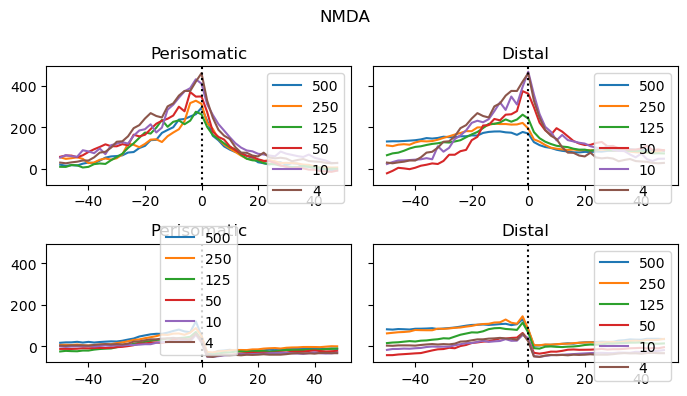

In [9]:
fig, ax = plt.subplots(2,2,figsize=(7,4), sharey=True)
plot_sta_means(lag_sta, ['prox500_dist_4','prox250_dist_4','prox125_dist_4','prox50_dist_4','prox10_dist_4', 'prox4_dist_4'],
               'nmda_sta', 'apic', ax[0,0])
ax[0,0].set_title('Perisomatic')
plot_sta_means(lag_sta, ['prox4_dist_500','prox4_dist_250','prox4_dist_125','prox4_dist_50','prox4_dist_10', 'prox4_dist_4'],
               'nmda_sta', 'apic', ax[0,1])
ax[0,1].set_title('Distal')
plot_sta_means(lag_sta, ['prox500_dist_4','prox250_dist_4','prox125_dist_4','prox50_dist_4','prox10_dist_4', 'prox4_dist_4'],
               'nmda_sta', 'dend', ax[1,0])
ax[1,0].set_title('Perisomatic')
plot_sta_means(lag_sta, ['prox4_dist_500','prox4_dist_250','prox4_dist_125','prox4_dist_50','prox4_dist_10', 'prox4_dist_4'],
               'nmda_sta', 'dend', ax[1,1])
ax[1,1].set_title('Distal')
fig.suptitle('NMDA')
fig.tight_layout()


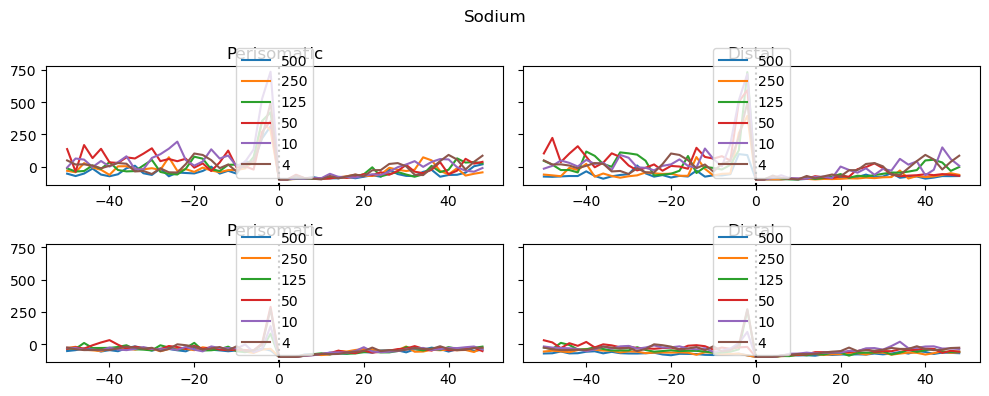

In [10]:
fig, ax = plt.subplots(2,2,figsize=(10,4), sharey=True)
plot_sta_means(lag_sta, ['prox500_dist_4','prox250_dist_4','prox125_dist_4','prox50_dist_4','prox10_dist_4', 'prox4_dist_4'],
               'na_sta', 'apic', ax[0,0])
ax[0,0].set_title('Perisomatic')
plot_sta_means(lag_sta, ['prox4_dist_500','prox4_dist_250','prox4_dist_125','prox4_dist_50','prox4_dist_10', 'prox4_dist_4'],
               'na_sta', 'apic', ax[0,1])
ax[0,1].set_title('Distal')
plot_sta_means(lag_sta, ['prox500_dist_4','prox250_dist_4','prox125_dist_4','prox50_dist_4','prox10_dist_4', 'prox4_dist_4'],
               'na_sta', 'dend', ax[1,0])
ax[1,0].set_title('Perisomatic')
plot_sta_means(lag_sta, ['prox4_dist_500','prox4_dist_250','prox4_dist_125','prox4_dist_50','prox4_dist_10', 'prox4_dist_4'],
               'na_sta', 'dend', ax[1,1])
ax[1,1].set_title('Distal')
fig.suptitle('Sodium')
fig.tight_layout()

In [12]:
# Plot the STA across Na and NMDA events for each simulation
def plot_sta_sim(sta_dict):
    fig,ax = plt.subplots(2,2)
    plot_sta_im(sta_dict['nmda_sta'].loc['apic','sta'], ax[0,0])
    ax[0,0].set_title('NMDA Apical')
    plot_sta_im(sta_dict['nmda_sta'].loc['dend','sta'], ax[1,0])
    ax[1,0].set_title('NMDA Basal')
    plot_sta_im(sta_dict['na_sta'].loc['apic','sta'], ax[0,1])
    ax[0,1].set_title('Na Apical')
    plot_sta_im(sta_dict['na_sta'].loc['dend','sta'], ax[1,1])
    ax[1,1].set_title('Na Basal')
    fig.supxlabel('Time from action potential (ms)')
    fig.supylabel('Electrotonic quantile 90->0')
    fig.suptitle('Coordination of dendritic events and action potentials in ' + sta_dict['sim_name'])
    fig.tight_layout()

def plot_sta_sim_ca(sta_dict):
    fig,ax = plt.subplots()
    plot_sta_im(sta_dict['ca_sta'].loc['apic','sta'], ax)
    ax.set_title('Ca Apical')
    fig.supxlabel('Time from action potential (ms)')
    fig.supylabel('Electrotonic quantile 90->0')
    fig.suptitle('Coordination of dendritic events and action potentials in ' + sta_dict['sim_name'])
    fig.tight_layout()

def plot_sta_sim_stair(sta_dict):
    fig,ax = plt.subplots(2,2)
    plot_sta_stair(sta_dict['nmda_sta'].loc['apic','sta'], ax[0,0])
    ax[0,0].set_title('NMDA Apical')
    plot_sta_stair(sta_dict['nmda_sta'].loc['dend','sta'], ax[1,0])
    ax[1,0].set_title('NMDA Basal')
    plot_sta_stair(sta_dict['na_sta'].loc['apic','sta'], ax[0,1])
    ax[0,1].set_title('Na Apical')
    plot_sta_stair(sta_dict['na_sta'].loc['dend','sta'], ax[1,1])
    ax[1,1].set_title('Na Basal')
    fig.supxlabel('Time from action potential (ms)')
    fig.supylabel('Electrotonic quantile 90->0')
    fig.suptitle('Coordination of dendritic events and action potentials in ' + sta_dict['sim_name'])
    fig.tight_layout()

# 4.0 Action Potential Firing Rates Across E/I Lags

Analyze how varying the E/I lag affects somatic action potential firing rate (corresponding to Figure 4G in the paper).

Key findings:
- Increasing the lag of **perisomatic inhibition** lowered action potential firing
- For **distal dendritic inhibition**, firing rate decreased out to a lag of 125 ms, then returned to normal at 500 ms
- The normal 4 ms E/I lag produced maximal conversion of dendritic spiking events into action potentials

This demonstrates that distal and perisomatic inhibition modulate the coupling between synaptic drive and spiking through distinct processes.

In [15]:
spk_dict = {}
for sim_name, sim_dict in sim_df.iterrows():
    print(sim_name)
    spk_dict[sim_name] = [load_spike_h5(os.path.join(sim_dict['RootDir'], sim_dict['SimDir'], sim_dict['APFile']))]

# convert spk_dict to a dataframe where each row is a different key/value pair
spk_df = pd.DataFrame.from_dict(spk_dict, orient='index', columns=['spk_times'])

spk_df['spk_rate'] = spk_df['spk_times'].apply(lambda x: len(x) / ((sim_win[1] - sim_win[0]) / (1000 * samps_per_ms)))
spk_df['spk_max'] = spk_df['spk_times'].apply(lambda x: max(x))
spk_df

prox500_dist_4
prox250_dist_4
prox125_dist_4
prox50_dist_4
prox10_dist_4
prox4_dist_4
prox4_dist_500
prox4_dist_250
prox4_dist_125
prox4_dist_50
prox4_dist_10
proxn50_dist_4
proxn10_dist_4
proxn500_dist_4
prox4_dist_n500
prox4_dist_n50
prox4_dist_n10


,spk_times,spk_rate,spk_max
prox500_dist_4,"[2269, 2337, 23917, 26440, 31481, 32097, 44954...",2.160000,1491366
prox250_dist_4,"[4772, 7064, 12779, 12883, 21616, 23836, 24007...",2.333333,1489294
prox125_dist_4,"[34, 5214, 6201, 10235, 10382, 21551, 26805, 2...",2.553333,1486264
prox50_dist_4,"[39, 9905, 10188, 10252, 10342, 10402, 21572, ...",2.833333,1488558
prox10_dist_4,"[41, 2319, 4039, 19305, 21571, 21716, 22038, 2...",3.220000,1488331
prox4_dist_4,"[38, 3466, 4642, 8887, 10029, 21584, 22368, 26...",3.253333,1485933
prox4_dist_500,"[4062, 8726, 9089, 9278, 13822, 13882, 14285, ...",3.166667,1492946
prox4_dist_250,"[11880, 11967, 24024, 24260, 29382, 30944, 310...",2.793333,1490362
prox4_dist_125,"[36, 8323, 10538, 11574, 22758, 28386, 28450, ...",2.473333,1487175
prox4_dist_50,"[4468, 4586, 8518, 21957, 29326, 40531, 40645,...",2.606667,1486551


In [16]:
# convert index to column
spk_df.reset_index(inplace=True)
spk_df.rename(columns={'index':'sim_name'}, inplace=True)

In [17]:
# create column with the lag on proximal dendrites
spk_df['prox_lag'] = spk_df['sim_name'].apply(lambda x: np.array(re.findall(r'prox(\d+)', x)).astype(int))
spk_df['dist_lag'] = spk_df['sim_name'].apply(lambda x: np.array(re.findall(r'dist_(\d+)', x)).astype(int))
spk_df


,sim_name,spk_times,spk_rate,spk_max,prox_lag,dist_lag
0,prox500_dist_4,"[2269, 2337, 23917, 26440, 31481, 32097, 44954...",2.160000,1491366,[500],[4]
1,prox250_dist_4,"[4772, 7064, 12779, 12883, 21616, 23836, 24007...",2.333333,1489294,[250],[4]
2,prox125_dist_4,"[34, 5214, 6201, 10235, 10382, 21551, 26805, 2...",2.553333,1486264,[125],[4]
3,prox50_dist_4,"[39, 9905, 10188, 10252, 10342, 10402, 21572, ...",2.833333,1488558,[50],[4]
4,prox10_dist_4,"[41, 2319, 4039, 19305, 21571, 21716, 22038, 2...",3.220000,1488331,[10],[4]
5,prox4_dist_4,"[38, 3466, 4642, 8887, 10029, 21584, 22368, 26...",3.253333,1485933,[4],[4]
6,prox4_dist_500,"[4062, 8726, 9089, 9278, 13822, 13882, 14285, ...",3.166667,1492946,[4],[500]
7,prox4_dist_250,"[11880, 11967, 24024, 24260, 29382, 30944, 310...",2.793333,1490362,[4],[250]
8,prox4_dist_125,"[36, 8323, 10538, 11574, 22758, 28386, 28450, ...",2.473333,1487175,[4],[125]
9,prox4_dist_50,"[4468, 4586, 8518, 21957, 29326, 40531, 40645,...",2.606667,1486551,[4],[50]


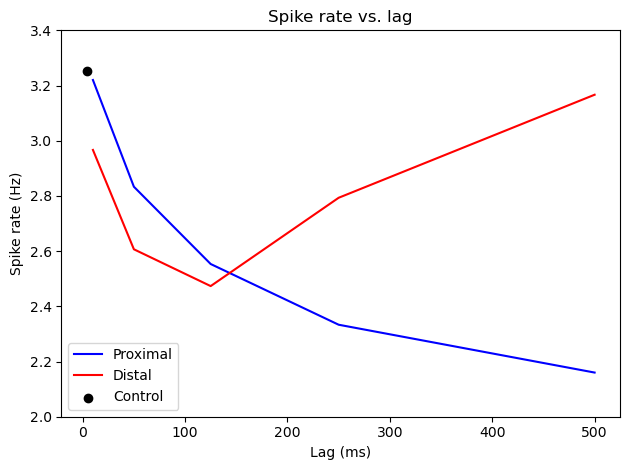

In [18]:
control_spk = spk_df['spk_rate'].loc[(spk_df['prox_lag']==4) & (spk_df['dist_lag']==4)].values
prox_spks = spk_df[['spk_rate', 'prox_lag']].loc[(spk_df['prox_lag']!=4) & spk_df['prox_lag'].apply(lambda x: len(x)!=0)].values
dist_spks = spk_df[['spk_rate', 'dist_lag']].loc[(spk_df['dist_lag']!=4) & spk_df['dist_lag'].apply(lambda x: len(x)!=0)].values

fig, ax = plt.subplots()
ax.plot(prox_spks[:,1], prox_spks[:,0], label='Proximal', color='blue')
ax.plot(dist_spks[:,1], dist_spks[:,0], label='Distal', color='red')
ax.scatter(4, control_spk, label='Control', color='black')
ax.legend()
ax.set_xlabel('Lag (ms)')
ax.set_ylabel('Spike rate (Hz)')
ax.set_title('Spike rate vs. lag')
ax.set_ylim([2, 3.4])
fig.tight_layout()